In [68]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch import nn

In [69]:
from typing import Any


class AbstracMultiLoraModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(10, 10)
        self.linear = nn.Linear(10, 10)
        self.lm_head = nn.Linear(10, 10)

    def linear_lora(
        self,
        x: torch.Tensor,                 # [batch_size, seq_len, in_features]
        loras_a: torch.Tensor,           # [num_loras, in_features, rank]
        loras_b: torch.Tensor,           # [num_loras, rank, in_features]
        lora_indices: torch.LongTensor,  # [batch_size]
    ) -> torch.Tensor:
        raise NotImplementedError()

    def forward(self, input_ids, loras_a, loras_b, lora_indices):
        x = self.embedding(input_ids)
        x = self.linear_lora(x, loras_a, loras_b, lora_indices)
        x= self.lm_head(x)
        return x

In [70]:
class LoopMultiLoraModel(AbstracMultiLoraModel):
    def linear_lora(
        self,
        x: torch.Tensor,                 # [batch_size, seq_len, in_features]
        loras_a: torch.Tensor,           # [num_loras, in_features, rank]
        loras_b: torch.Tensor,           # [num_loras, rank, in_features]
        lora_indices: torch.LongTensor,  # [batch_size]
    ) -> torch.Tensor:
        y = self.linear(x)
        for batch_idx, lora_idx in enumerate(lora_indices.numpy()):
            lora_a = loras_a[lora_idx]
            lora_b = loras_b[lora_idx]
            y[batch_idx] = x[batch_idx] @ lora_a @ lora_b
        return y

In [71]:
# toy example of a detokenizer. The vocabular only consists of 10 words (different colors)
detokenizer = [
    "red",
    "orange",
    "yellow",
    "green",
    "blue",
    "indigo",
    "violet",
    "magenta",
    "marigold",
    "chartreuse",
]

In [72]:
# dummy inputs
input_ids = torch.LongTensor([[0, 1, 2, 3, 4, 5, 6, 7]])

In [73]:
torch.manual_seed(42)

In [74]:
def generate_token(model, **kw):
    with torch.no_grad():
        logits = model(**kw)
        last_logits = logits[:, -1, :]
        next_token_ids = last_logits.argmax(dim=1)

    return [detokenizer[token_id] for token_id in next_token_ids]
    

In [93]:
model = LoopMultiLoraModel()

In [76]:
# constants
bs = 1
num_loras = 64
h = 10
r = 2

loras_a = torch.randn(num_loras, h, r)
loras_b = torch.randn(num_loras, r, h)

for i in range(10):
    lora_indices = torch.randint(num_loras, (bs, ), dtype=torch.long)
    next_token = generate_token(
        model,
        input_ids = input_ids,
        loras_a = loras_a,
        loras_b = loras_b,
        lora_indices = lora_indices
    )
    print(next_token)

['orange']
['yellow']
['chartreuse']
['yellow']
['marigold']
['yellow']
['red']
['orange']
['violet']
['chartreuse']


In [94]:
# constants
seq_len = 8
vocab_size = 10
nsamples = 500
max_batch_size = 64

def benchmark(model):
    avg_latencies = []
    for bs in range(1, max_batch_size + 1):
        latencies = []
        for _ in range(nsamples):
            input_ids = torch.randint(vocab_size, (bs, seq_len), dtype=torch.long)
            lora_indices = torch.randint(num_loras, (bs, ), dtype=torch.long)

            t0 = time.time()

            next_token = generate_token(model,
                                        input_ids = input_ids,
                                        loras_a=loras_a,
                                        loras_b=loras_b,
                                        lora_indices=lora_indices
                                        )
            latencies.append(time.time() - t0)
        latency_s = sum(latencies) / len(latencies)
        avg_latencies.append(latency_s)
        print(bs, latency_s)

    return avg_latencies

In [95]:
avg_latencies_loop = benchmark(model)

1 5.057859420776367e-05
2 2.8187274932861328e-05
3 6.450891494750976e-05
4 9.853696823120117e-05
5 9.709548950195312e-05
6 0.00011804437637329101
7 0.0001149001121520996
8 0.00012849855422973633
9 0.00017630529403686522
10 0.00014143753051757812
11 0.00015416955947875977
12 0.00016078853607177733
13 0.000152069091796875
14 0.00017476654052734375
15 0.00020813608169555664
16 0.00021067905426025392
17 0.00022092676162719727
18 0.00020967435836791992
19 0.0002420191764831543
20 0.00026332807540893556
21 0.00026108694076538085
22 0.00027078866958618164
23 0.0002666621208190918
24 0.0002844386100769043
25 0.0002864017486572266
26 0.0002833719253540039
27 0.0002992515563964844
28 0.00033617782592773436
29 0.00034493112564086916
30 0.0003465356826782227
31 0.00033122777938842773
32 0.00037866878509521483
33 0.0003999919891357422
34 0.00038334846496582034
35 0.00038259077072143555
36 0.0004167323112487793
37 0.00046598052978515624
38 0.0004339718818664551
39 0.0004159541130065918
40 0.00046667

In [96]:
class GatheradMultiLoraModel(AbstracMultiLoraModel):
    def linear_lora(
        self,
        x: torch.Tensor,                 # [batch_size, seq_len, in_features]
        loras_a: torch.Tensor,           # [num_loras, in_features, rank]
        loras_b: torch.Tensor,           # [num_loras, rank, in_features]
        lora_indices: torch.LongTensor,  # [batch_size]
    ) -> torch.Tensor:
        y = self.linear(x)
        lora_a = torch.index_select(loras_a, 0, lora_indices) # (batch_size, in_features, lora_rank)
        lora_b = torch.index_select(loras_b, 0, lora_indices) # (batch_size, in_features, lora_rank)
        y += x @ lora_a @ lora_b
        return y

In [97]:
model = GatheradMultiLoraModel()

In [98]:
avg_latencies_gathered = benchmark(model)

1 5.156898498535156e-05
2 4.956293106079102e-05
3 6.907510757446289e-05
4 4.9541473388671875e-05
5 6.084108352661133e-05
6 8.453989028930664e-05
7 8.803987503051758e-05
8 9.208726882934571e-05
9 8.121442794799804e-05
10 8.44864845275879e-05
11 7.932043075561524e-05
12 7.796764373779296e-05
13 8.557367324829102e-05
14 8.655595779418945e-05
15 7.567834854125977e-05
16 9.207963943481445e-05
17 8.237266540527343e-05
18 9.278011322021485e-05
19 9.627294540405273e-05
20 8.725833892822266e-05
21 0.00010141229629516601
22 9.35678482055664e-05
23 9.932661056518555e-05
24 0.00010474777221679687
25 9.592056274414062e-05
26 0.00011398696899414063
27 0.00010856533050537109
28 0.00010969638824462891
29 0.00010480356216430663
30 0.00012505626678466797
31 0.0001235499382019043
32 0.00010770654678344727
33 0.00012173891067504883
34 0.00011733484268188476
35 0.00012193727493286133
36 0.00011889171600341797
37 0.0001265134811401367
38 0.00011555624008178711
39 0.0001299266815185547
40 0.00012979030609130

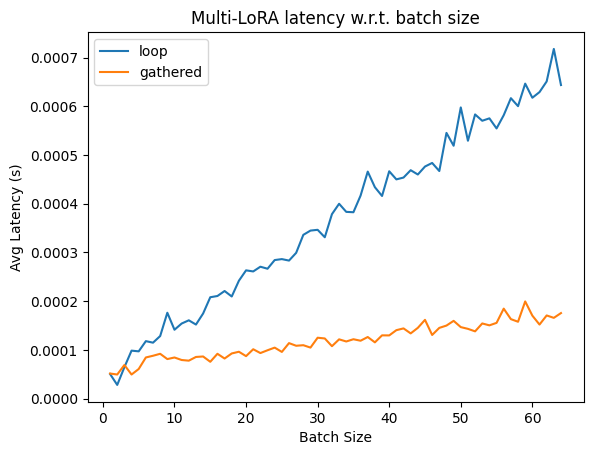

In [99]:
x = list(range(1, max_batch_size + 1))
plt.plot(x, avg_latencies_loop, label="loop")
plt.plot(x, avg_latencies_gathered, label="gathered")

plt.xlabel('Batch Size')
plt.ylabel('Avg Latency (s)')
plt.title('Multi-LoRA latency w.r.t. batch size')
plt.legend()

plt.show()